In [1]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [2]:
IN_pair = 'G140S-Q148H'
# IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'

re_mutation = functions.unreduced_to_reduced_pair(IN_redux, IN_pair)
print(re_mutation)

m1,m2 = functions.split_pairs(re_mutation)
# print(m1,m2)
_,pos1,mt1 = functions.split_pair(m1)
# print (mt1)
_,pos2,mt2 = functions.split_pair(m2)
seq_with_mutation = []
for seq in IN_all_seq:
    if seq[pos1 - 1] == mt1 and seq[pos2 - 1] == mt2:
        seq_with_mutation.append(seq)

seq_without_mutation = []
for seq in IN_all_seq:
    if seq[pos1 - 1] != mt1 and seq[pos2 - 1] != mt2:
        seq_without_mutation.append(seq)
    
print('len seq with mutaiton', len(seq_with_mutation))
print('len seq without mutaiton', len(seq_without_mutation))


C140D-D148B
len seq with mutaiton 221
len seq without mutaiton 971


In [3]:
import numpy as np

# Encode sequences with energy differences
def encode_sequences_with_energy_diff(sequences):
    encoded = []
    seq_count = 0
    for seq in sequences:
        seq_encoded = []
        # Calculate the delta E residue for the entire sequence
        for pos in range(len(seq)):
            de_residue = explore.calculate_de_residue(pos, seq, IN_pair, IN_J, IN_redux)
            # print(f"Position {pos + 1}, Sequence: {seq_count}, ΔE_residue: {de_residue}")
            seq_encoded.append(de_residue)

        encoded.append(seq_encoded)
        seq_count += 1
    return np.array(encoded)

# Example usage
wildtype_seq = IN_consensus_seq  # Wildtype sequence
mutant_seq = list(IN_consensus_seq)  # Start with the wildtype
mutant_seq[pos1 - 1] = mt1  # Apply first mutation
mutant_seq[pos2 - 1] = mt2  # Apply second mutation
mutant_seq = ''.join(mutant_seq)

encoded_with_mutation = encode_sequences_with_energy_diff(seq_with_mutation)
encoded_without_mutation = encode_sequences_with_energy_diff(seq_without_mutation)



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Create labels for the datasets
labels_with_mutation = np.ones(len(encoded_with_mutation))
labels_without_mutation = np.zeros(len(encoded_without_mutation))

# Combine the datasets and labels
X = np.vstack((encoded_with_mutation, encoded_without_mutation))
y = np.hstack((labels_with_mutation, labels_without_mutation))

# Split into train and test sets, with 20 samples in the test set for each class
X_train_with, X_test_with, y_train_with, y_test_with = train_test_split(
    encoded_with_mutation, labels_with_mutation, test_size=20, random_state=42
)
X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(
    encoded_without_mutation, labels_without_mutation, test_size=20, random_state=42
)

# Combine the train and test sets
X_train = np.vstack((X_train_with, X_train_without))
y_train = np.hstack((y_train_with, y_train_without))
X_test = np.vstack((X_test_with, X_test_without))
y_test = np.hstack((y_test_with, y_test_without))

# Train a Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.65
Classification Report:
               precision    recall  f1-score   support

         0.0       0.59      0.95      0.73        20
         1.0       0.88      0.35      0.50        20

    accuracy                           0.65        40
   macro avg       0.73      0.65      0.62        40
weighted avg       0.73      0.65      0.62        40



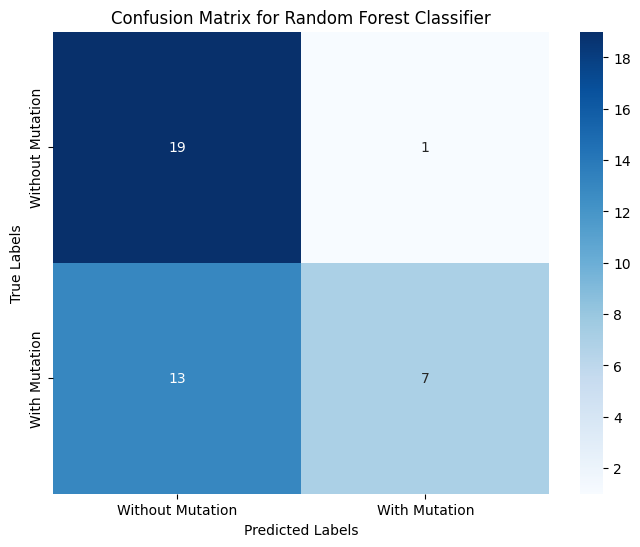

In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Without Mutation', 'With Mutation'], yticklabels=['Without Mutation', 'With Mutation'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy (Elastic Net): 0.7
Classification Report (Elastic Net):
               precision    recall  f1-score   support

         0.0       0.63      0.95      0.76        20
         1.0       0.90      0.45      0.60        20

    accuracy                           0.70        40
   macro avg       0.77      0.70      0.68        40
weighted avg       0.77      0.70      0.68        40



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


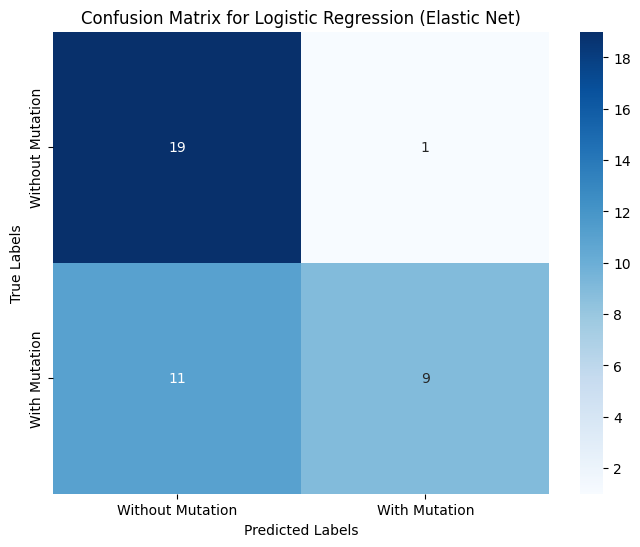

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Train a Logistic Regression classifier with Elastic Net regularization
clf_elastic_net = LogisticRegression(
    penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42
)
clf_elastic_net.fit(X_train, y_train)

# Make predictions
y_pred_elastic_net = clf_elastic_net.predict(X_test)

# Evaluate the classifier
print("Accuracy (Elastic Net):", accuracy_score(y_test, y_pred_elastic_net))
print("Classification Report (Elastic Net):\n", classification_report(y_test, y_pred_elastic_net))

# Compute the confusion matrix
cm_elastic_net = confusion_matrix(y_test, y_pred_elastic_net)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_elastic_net, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Without Mutation', 'With Mutation'],
    yticklabels=['Without Mutation', 'With Mutation']
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression (Elastic Net)')
plt.show()

SVM Accuracy: 0.725
SVM Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.95      0.78        20
         1.0       0.91      0.50      0.65        20

    accuracy                           0.72        40
   macro avg       0.78      0.72      0.71        40
weighted avg       0.78      0.72      0.71        40



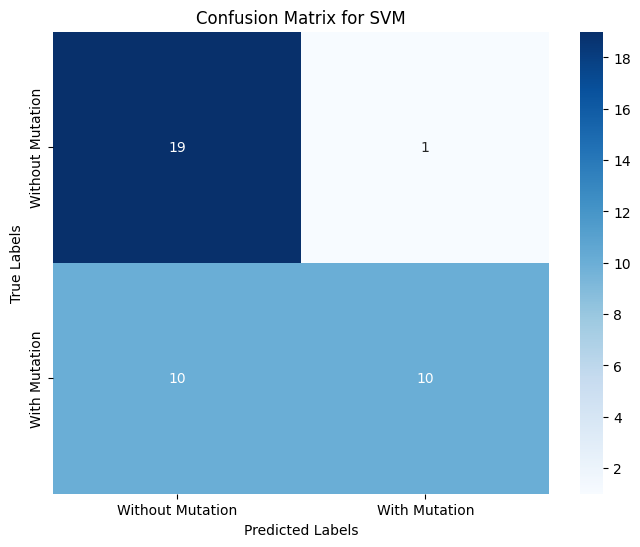

KNN Accuracy: 0.625
KNN Classification Report:
               precision    recall  f1-score   support

         0.0       0.58      0.90      0.71        20
         1.0       0.78      0.35      0.48        20

    accuracy                           0.62        40
   macro avg       0.68      0.62      0.59        40
weighted avg       0.68      0.62      0.59        40



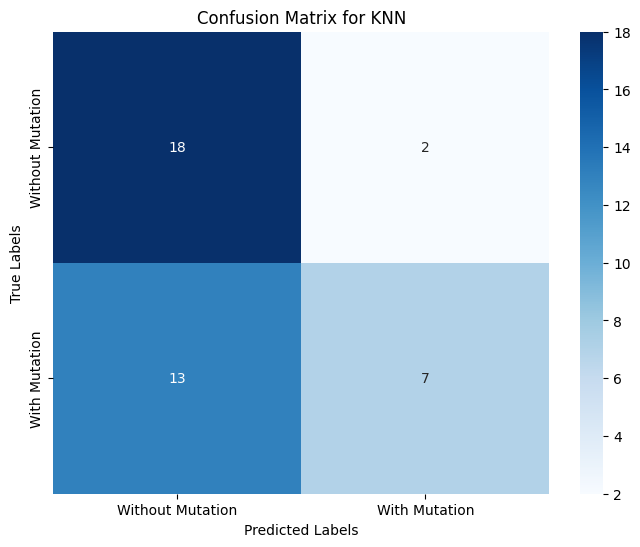

In [7]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Train and evaluate SVM
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# Compute confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix for SVM
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Without Mutation', 'With Mutation'], yticklabels=['Without Mutation', 'With Mutation'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for SVM')
plt.show()

# Train and evaluate KNN
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

# Compute confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix for KNN
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Without Mutation', 'With Mutation'], yticklabels=['Without Mutation', 'With Mutation'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for KNN')
plt.show()